# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning



In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
football is a beloved sport worldwide
billions of fans follow it passionately
two teams of eleven players compete
the goal is to score goals
ball must enter the opponents net
sport originated in england long ago
fifa world cup is biggest tournament
uefa champions league attracts huge audiences
pele and maradona were football legends
messi and ronaldo are modern greats
football brings people together always
it is more than just sport
crowd roars when a goal scores
penalty shootouts create unbearable tension
lifting the trophy brings pure joy
el clasico is a famous rivalry
real madrid and barcelona always compete
manchester derby is watched by millions
football teaches teamwork and discipline
leadership and grace are also learned
small grounds to massive stadiums exist
camp nou and wembley are iconic
football truly unites the entire world
'''
print(corpus)


football is a beloved sport worldwide
billions of fans follow it passionately
two teams of eleven players compete
the goal is to score goals
ball must enter the opponents net
sport originated in england long ago
fifa world cup is biggest tournament
uefa champions league attracts huge audiences
pele and maradona were football legends
messi and ronaldo are modern greats
football brings people together always
it is more than just sport
crowd roars when a goal scores
penalty shootouts create unbearable tension
lifting the trophy brings pure joy
el clasico is a famous rivalry
real madrid and barcelona always compete
manchester derby is watched by millions
football teaches teamwork and discipline
leadership and grace are also learned
small grounds to massive stadiums exist
camp nou and wembley are iconic
football truly unites the entire world



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 105
X shape: (112, 5)
y shape: (112,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

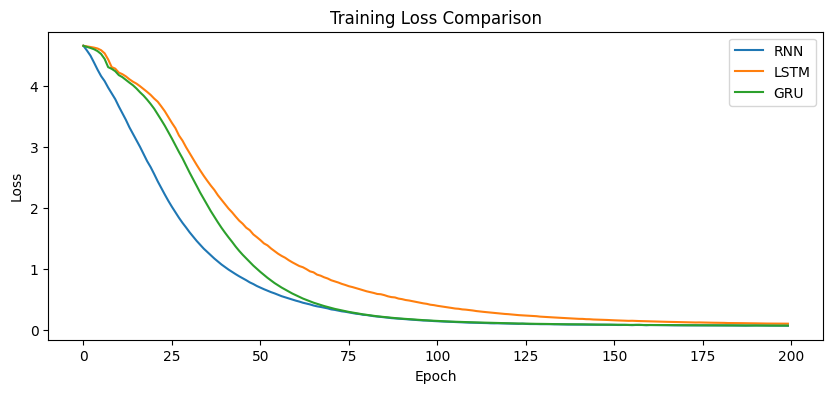

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "football is", 10))
print("LSTM:", generate_text(lstm_model, "football is", 10))
print("GRU :", generate_text(gru_model, "football is", 10))

RNN : football is a beloved sport worldwide exist england long ago goals just
LSTM: football is a beloved sport worldwide millions sport long ago ago ago
GRU : football is a beloved sport worldwide worldwide compete ago ago net net


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

# My Conclusion

In this project, I implemented and compared three sequence models Vanilla RNN, LSTM, and GRU for text generation using a football-based corpus consisting of 23 lines and 105 unique words. All three models were trained for 200 epochs with an embedding dimension of 64 and 128 hidden units. After training, each model was given the seed text "football is" and asked to predict the next 10 words. All three models correctly predicted the first few words as "football is a beloved sport worldwide" which is an actual line from the corpus, proving that all models successfully learned the patterns in the training data. After that point, the Vanilla RNN performed the best among the three, generating words like "exist", "england", "long ago", and "goals" which are all relevant to the corpus. The LSTM and GRU models started repeating words like "ago ago ago" and "net net" after the initial correct sequence, which shows that on medium sized datasets these gated models tend to overfit and get stuck in a prediction loop. This does not mean LSTM and GRU are weak in fact they are theoretically more powerful than Vanilla RNN because LSTM uses input, forget, and output gates to preserve long term memory, while GRU uses reset and update gates making it faster and simpler than LSTM. Their true strength shows on larger and more complex datasets. The training loss graph showed that all three models reduced their loss steadily over 200 epochs, confirming that learning took place in all cases. Overall this project gave me a clear and practical understanding of how RNN, LSTM, and GRU differ from each other in terms of architecture, memory handling, and text generation quality.